In [4]:
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch
from torchvision import datasets

In [5]:
print("CUDA available:", torch.cuda.is_available())
print("Current device:", torch.cuda.current_device())
print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
print("PyTorch version:", torch.__version__)

CUDA available: True
Current device: 0
Device name: NVIDIA GeForce RTX 3060 Laptop GPU
GPU Name: NVIDIA GeForce RTX 3060 Laptop GPU
PyTorch version: 2.7.0+cu118


# Constructing the Dataset class

In [6]:
class FERDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        pixels = np.fromstring(self.df.loc[idx, 'pixels'], sep=' ', dtype=np.uint8)
        image = pixels.reshape(48, 48)  # grayscale
        image = Image.fromarray(image).convert("RGB")  # convert to RGB
        label = int(self.df.loc[idx, 'emotion'])

        if self.transform:
            image = self.transform(image)

        return image, label

# Preprocessing

In [7]:
# Image preprocessing: training set (including data augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)  
])

# Test set preprocessing: no enhancement
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


# Load Dataset

In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

# Paths
train_dir = r"C:\Users\user\Downloads\archive\train"
test_dir = r"C:\Users\user\Downloads\archive\test"

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

# Split training dataset into training and validation sets
train_idx, val_idx = train_test_split(
    list(range(len(train_dataset))),
    test_size=0.2,
    stratify=train_dataset.targets,  # ensures balanced split across classes
    random_state=42
)

train_split = Subset(train_dataset, train_idx)
val_split = Subset(train_dataset, val_idx)

# Define DataLoaders
train_loader = DataLoader(train_split, batch_size=64, shuffle=True)
val_loader = DataLoader(val_split, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [9]:
print(train_dataset.class_to_idx)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


# Model Building CNN

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EmotionCNN(nn.Module):
    def __init__(self):
        super(EmotionCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Flatten + Fully connected layers
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 7)  # Output: 7 emotion classes

    def forward(self, x):
        # Convolution + ReLU + Pooling
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # No softmax here; use CrossEntropyLoss later
        
        return x

# Model Training CNN

In [11]:
from tqdm.notebook import tqdm

def train_model(model, train_loader, val_loader, optimizer, loss_fn, device, num_epochs=30, save_path="best_model.pth"):
    train_losses, val_accuracies = [], []
    best_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_acc = correct / total
        val_accuracies.append(val_acc)

        print(f"\nEpoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Acc = {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print(f"Saved best model to {save_path}")

    return train_losses, val_accuracies

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

emotioncnn = EmotionCNN().to(device)
optimizer_cnn = torch.optim.Adam(emotioncnn.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

#start training cnn model
train_losses_cnn, val_acc_cnn = train_model(
    emotioncnn, train_loader, val_loader,
    optimizer_cnn, criterion, device,
    num_epochs=20, save_path="best_cnn_model.pth")

Epoch 1/20:   0%|          | 0/359 [00:00<?, ?it/s]


Epoch 1: Train Loss = 1.7068, Val Acc = 0.3800
Saved best model to best_cnn_model.pth


Epoch 2/20:   0%|          | 0/359 [00:00<?, ?it/s]


Epoch 2: Train Loss = 1.5537, Val Acc = 0.4201
Saved best model to best_cnn_model.pth


Epoch 3/20:   0%|          | 0/359 [00:00<?, ?it/s]

...


Epoch 18: Train Loss = 0.9485, Val Acc = 0.5394
Saved best model to best_cnn_model.pth


Epoch 19/20:   0%|          | 0/359 [00:00<?, ?it/s]


Epoch 19: Train Loss = 0.9153, Val Acc = 0.5366


Epoch 20/20:   0%|          | 0/359 [00:00<?, ?it/s]


Epoch 20: Train Loss = 0.8884, Val Acc = 0.5373


# Model Building ResNet

In [13]:
from torchvision import models
import torch.nn as nn

resnet = models.resnet18(pretrained=True)

for name, param in resnet.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

resnet.fc = nn.Linear(resnet.fc.in_features, 7)
resnet = resnet.to(device)

C:\Users\user\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Model training ResNet

In [14]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(filter(lambda p: p.requires_grad, resnet.parameters()), lr=0.0001, weight_decay=1e-5)


from torchvision import transforms
transform_train = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [15]:
train_losses_resnet, val_acc_resnet = train_model(
    resnet,
    train_loader,
    val_loader,
    optimizer_resnet,
    criterion,
    device,
    num_epochs=50, 
    save_path="best_resnet_model_v2.pth"
)

Epoch 1/50:   0%|          | 0/359 [00:00<?, ?it/s]


Epoch 1: Train Loss = 1.2894, Val Acc = 0.5773
Saved best model to best_resnet_model_v2.pth


Epoch 2/50:   0%|          | 0/359 [00:00<?, ?it/s]


Epoch 2: Train Loss = 1.0479, Val Acc = 0.5923
Saved best model to best_resnet_model_v2.pth


Epoch 3/50:   0%|          | 0/359 [00:00<?, ?it/s]

...


Epoch 39: Train Loss = 0.0847, Val Acc = 0.6369


Epoch 40/50:   0%|          | 0/359 [00:00<?, ?it/s]


Epoch 40: Train Loss = 0.0822, Val Acc = 0.6451


Epoch 41/50:   0%|          | 0/359 [00:00<?, ?it/s]

KeyboardInterrupt: 

# Model Evaluation

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch  # Ensure torch is imported if not already

def evaluate_model(model, test_loader, class_names, device, model_name="Model"):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Classification Report
    print(f"\n{model_name} - Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Row-wise normalization

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name} - Confusion Matrix (Normalized %)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    # Accuracy score
    accuracy = np.mean(np.array(y_true) == np.array(y_pred))
    print(f"{model_name} Accuracy: {accuracy:.4f}")
    return accuracy


In [17]:
class_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']


EmotionCNN - Classification Report:
              precision    recall  f1-score   support

       Angry       0.43      0.44      0.43       958
     Disgust       0.83      0.22      0.34       111
        Fear       0.40      0.35      0.37      1024
       Happy       0.66      0.79      0.72      1774
         Sad       0.50      0.48      0.49      1233
    Surprise       0.43      0.40      0.41      1247
     Neutral       0.69      0.69      0.69       831

    accuracy                           0.54      7178
   macro avg       0.56      0.48      0.50      7178
weighted avg       0.53      0.54      0.53      7178



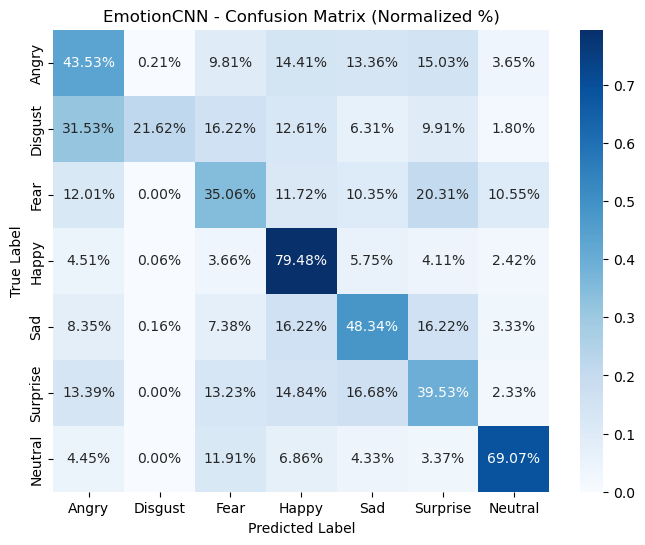

EmotionCNN Accuracy: 0.5396


In [18]:
#CNN best model
emotioncnn.load_state_dict(torch.load("best_cnn_model.pth"))
emotioncnn = emotioncnn.to(device)
acc_cnn = evaluate_model(emotioncnn, test_loader, class_names, device, model_name="EmotionCNN")


ResNet18 - Classification Report:
              precision    recall  f1-score   support

       Angry       0.57      0.52      0.54       958
     Disgust       0.71      0.56      0.63       111
        Fear       0.53      0.45      0.48      1024
       Happy       0.81      0.88      0.84      1774
         Sad       0.55      0.62      0.58      1233
    Surprise       0.51      0.50      0.51      1247
     Neutral       0.78      0.77      0.77       831

    accuracy                           0.64      7178
   macro avg       0.64      0.61      0.62      7178
weighted avg       0.64      0.64      0.64      7178



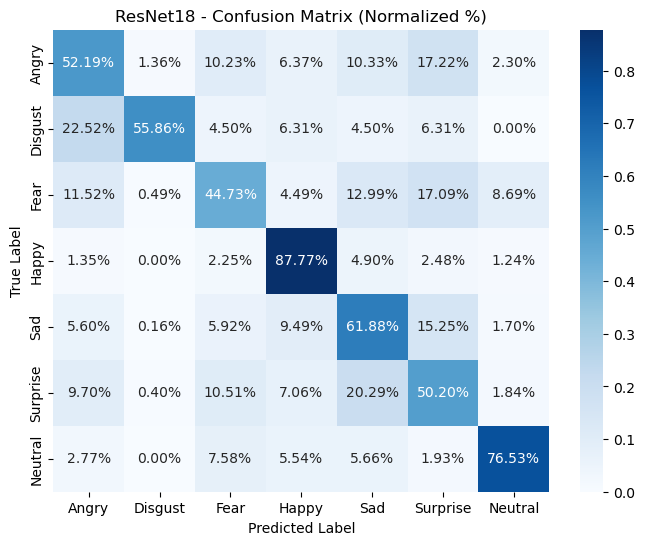

ResNet18 Accuracy: 0.6411


In [19]:
#ResNet18 best model
resnet.load_state_dict(torch.load("best_resnet_model_v2.pth"))
resnet = resnet.to(device)
acc_resnet = evaluate_model(resnet, test_loader, class_names, device, model_name="ResNet18")

# ROC Curve

In [20]:
#ROC Curve
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay

def plot_roc_curve_multiclass(model, test_loader, class_names, device, model_name="Model"):
    model.eval()
    y_score = []
    y_true = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            y_score.extend(outputs.cpu().numpy())
            y_true.extend(labels.numpy())

    y_score = np.array(y_score)
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    n_classes = len(class_names)

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")
    
    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

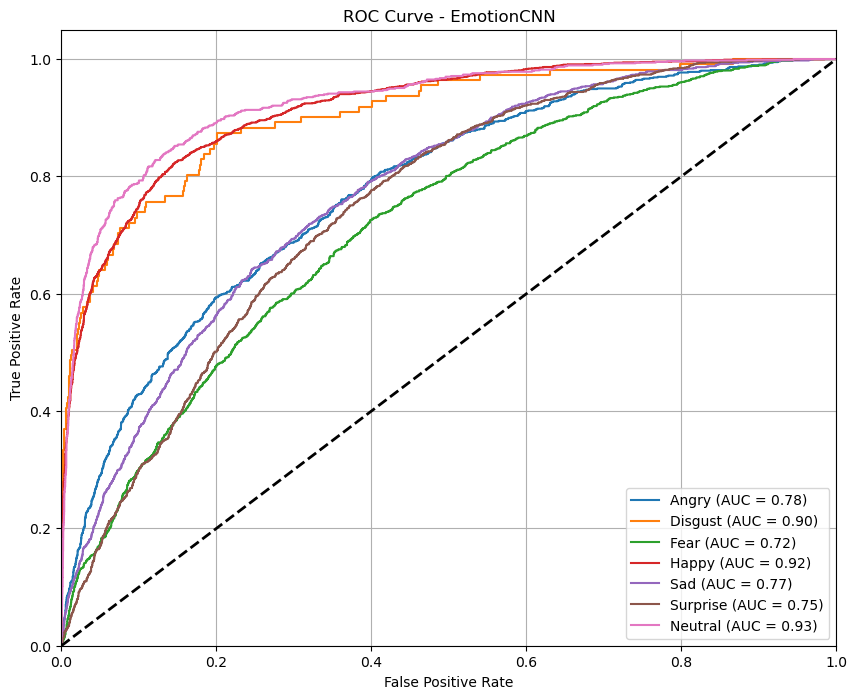

In [21]:
# CNN ROC
plot_roc_curve_multiclass(emotioncnn, test_loader, class_names, device, model_name="EmotionCNN")

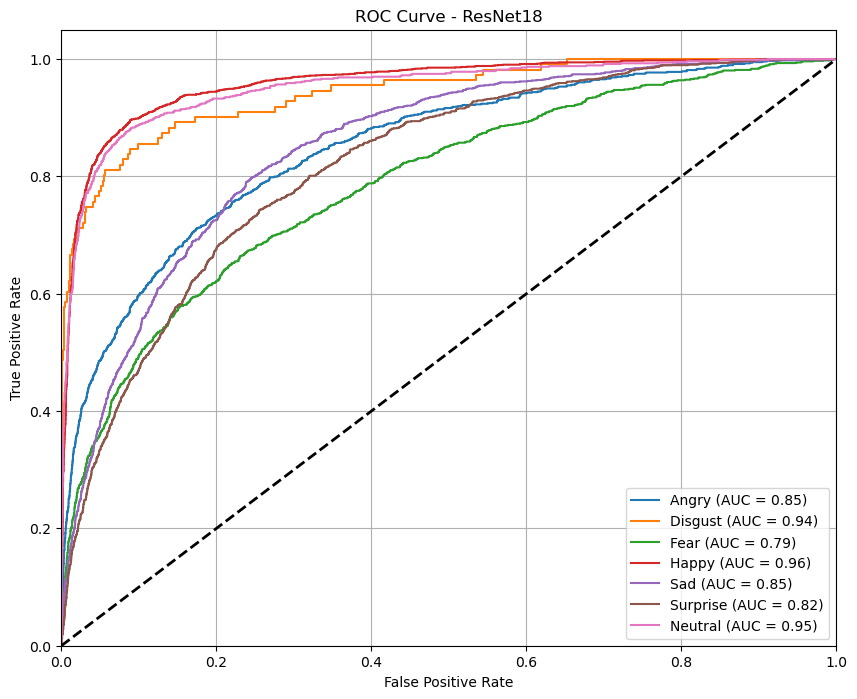

In [22]:
# ResNet ROC
plot_roc_curve_multiclass(resnet, test_loader, class_names, device, model_name="ResNet18")

# Final result

In [23]:
print("\nFinal Comparison Summary:")
print(f"EmotionCNN Accuracy: {acc_cnn:.4f}")
print(f"ResNet18 Accuracy  : {acc_resnet:.4f}")

if acc_resnet > acc_cnn:
    print("ResNet18 performed better overall.")
else:
    print("EmotionCNN performed better overall.")


Final Comparison Summary:
EmotionCNN Accuracy: 0.5396
ResNet18 Accuracy  : 0.6411
ResNet18 performed better overall.
